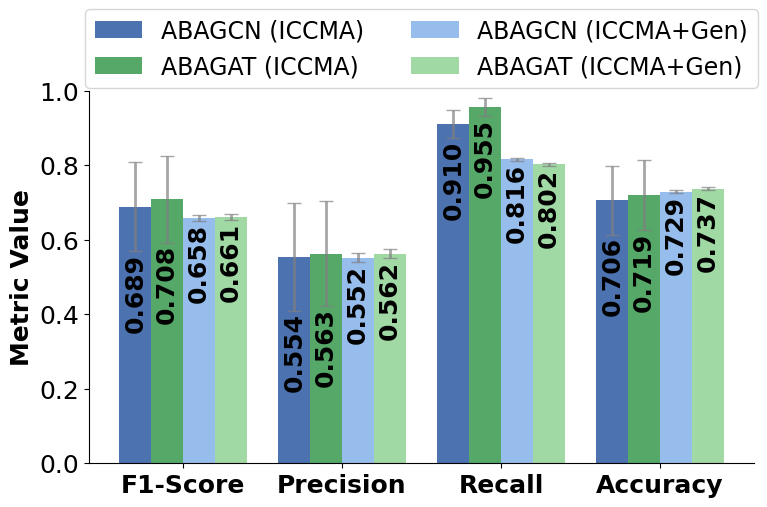

In [99]:
import matplotlib.pyplot as plt
import numpy as np
fontsize = 18
# Data
metrics = ['F1-Score', 'Precision', 'Recall', 'Accuracy']

# Values and errors
values_iccma_gcn = [0.6888, 0.5541, 0.9100, 0.7062]
errors_iccma_gcn = [0.1193, 0.1448, 0.0369, 0.0928]
values_iccma_gat = [0.7083, 0.5628, 0.9554, 0.7190]
errors_iccma_gat = [0.1164, 0.1406, 0.0241, 0.0937]
values_gen_gcn = [0.6582, 0.5517, 0.8156, 0.7289]
errors_gen_gcn = [0.0091, 0.0124, 0.0043, 0.0047]
values_gen_gat = [0.6611, 0.5622, 0.8022, 0.7368]
errors_gen_gat = [0.0087, 0.0123, 0.0049, 0.0043]

# Bar parameters
width = 0.2
offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * width
x = np.arange(len(metrics))

# Colors
colors = {
    'ABAGCN_ICCMA': '#4C72B0',
    'ABAGAT_ICCMA':'#55A868',
    'ABAGCN_Gen':  '#96BDEB',
    'ABAGAT_Gen':  '#A1D9A4'
}

fig, ax = plt.subplots(figsize=(8, 6))

# Plot clusters: ICCMA first, then ICCMA+Gen
ax.bar(x + offsets[0], values_iccma_gcn, width, yerr=errors_iccma_gcn, capsize=5,
       label='ABAGCN (ICCMA)', color=colors['ABAGCN_ICCMA'],
       error_kw={'ecolor':'gray','elinewidth':2,'alpha':0.7})
ax.bar(x + offsets[1], values_iccma_gat, width, yerr=errors_iccma_gat, capsize=5,
       label='ABAGAT (ICCMA)', color=colors['ABAGAT_ICCMA'],
       error_kw={'ecolor':'gray','elinewidth':2,'alpha':0.7})
ax.bar(x + offsets[2], values_gen_gcn,  width, yerr=errors_gen_gcn,  capsize=5,
       label='ABAGCN (ICCMA+Gen)', color=colors['ABAGCN_Gen'],
       error_kw={'ecolor':'gray','elinewidth':2,'alpha':0.7})
ax.bar(x + offsets[3], values_gen_gat,  width, yerr=errors_gen_gat,  capsize=5,
       label='ABAGAT (ICCMA+Gen)', color=colors['ABAGAT_Gen'],
       error_kw={'ecolor':'gray','elinewidth':2,'alpha':0.7})

# Annotations
offset_text = 0.005
for off, errs, vals in zip(offsets,
                           [errors_iccma_gcn, errors_iccma_gat, errors_gen_gcn, errors_gen_gat],
                           [values_iccma_gcn, values_iccma_gat, values_gen_gcn, values_gen_gat]):
    for xi, err, val in zip(x + off, errs, vals):
        bottom = val - err
        ax.text(xi, bottom - offset_text, f'{val:.3f}', ha='center', va='top',
                fontsize=fontsize, fontweight='bold', rotation=90)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=fontsize, fontweight='bold')
ax.set_ylabel('Metric Value', fontsize=fontsize, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.tick_params(axis='y', labelsize=fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.margins(x=0.05)

# Legend
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2, fontsize=fontsize-1)

plt.tight_layout(rect=[0,0,1,0.9])
plt.show()


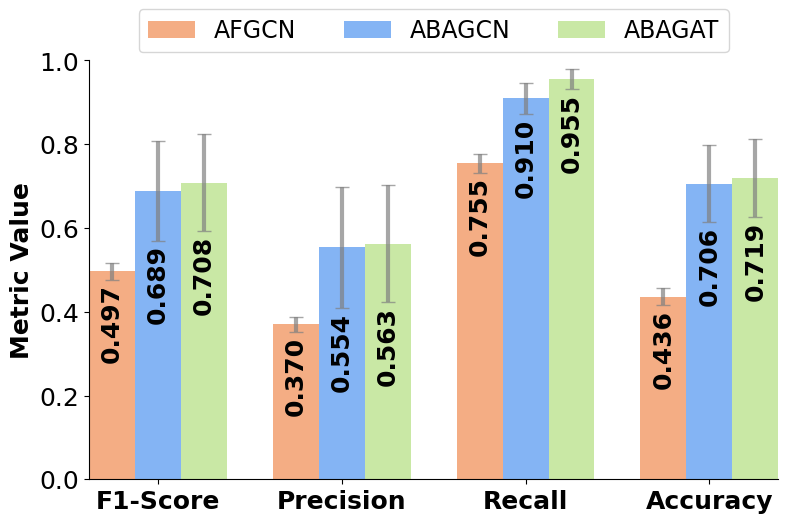

In [100]:
import matplotlib.pyplot as plt
import numpy as np

fontsize=18

# Data for the three series
metrics = ['F1-Score', 'Precision', 'Recall', 'Accuracy']

# AFGCN baseline
values_base = [0.4968, 0.3703, 0.7548, 0.4362]
errors_base = [0.0201, 0.0180, 0.0224, 0.0204]

# ABAGCN (Tuned GCN)
values_gcn = [0.6888, 0.5541, 0.9100, 0.7062]
errors_gcn = [0.1193, 0.1448, 0.0369, 0.0928]

# ABAGAT (Tuned GAT)
values_gat = [0.7083, 0.5628, 0.9554, 0.7190]
errors_gat = [0.1164, 0.1406, 0.0241, 0.0937]

# Compute group positions to match desired spacing
width = 0.2
cluster_width = 3 * width
gap = width  # same gap as bar width
group_spacing = cluster_width + gap
x = np.arange(len(metrics)) * group_spacing

# Colors
orange = '#F4AD84'  # AFGCN baseline
blue = '#84B4F4'    # ABAGCN
green = '#C9E8A5'   # ABAGAT

fig, ax = plt.subplots(figsize=(8, 6))

# Plot bars
bars_base = ax.bar(x - width, values_base, width, yerr=errors_base, capsize=5,
                   label='AFGCN', color=orange,
                   error_kw={'ecolor':'gray','elinewidth':3,'alpha':0.7}, zorder=1)
bars_gcn = ax.bar(x, values_gcn, width, yerr=errors_gcn, capsize=5,
                  label='ABAGCN', color=blue,
                  error_kw={'ecolor':'gray','elinewidth':3,'alpha':0.7}, zorder=1)
bars_gat = ax.bar(x + width, values_gat, width, yerr=errors_gat, capsize=5,
                  label='ABAGAT', color=green,
                  error_kw={'ecolor':'gray','elinewidth':3,'alpha':0.7}, zorder=1)

# Annotations below the start of the error bars
offset = 0.01
for bars, errs, vals in [(bars_base, errors_base, values_base),
                         (bars_gcn, errors_gcn, values_gcn),
                         (bars_gat, errors_gat, values_gat)]:
    for bar, err, val in zip(bars, errs, vals):
        bottom = val - err
        ax.text(bar.get_x() + bar.get_width()/2, bottom - offset,
                f'{val:.3f}', ha='center', va='top',
                fontsize=fontsize, fontweight='bold', rotation=90, zorder=2)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=fontsize, fontweight='bold')
ax.set_ylabel('Metric Value', fontsize=fontsize, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.tick_params(axis='y', labelsize=fontsize)
# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Apply same gap margins
ax.set_xlim(x[0] - (cluster_width/2), x[-1] + (cluster_width/2))

# Legend at top
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3, fontsize=fontsize-1)

plt.tight_layout(rect=[0,0,1,0.9])
plt.show()
